## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [5]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Plot style
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


from pathlib import Path

# Portable dataset path: works locally and in Google Colab when the CSV is in the
# same folder as the notebook. If you store it elsewhere, update DATA_PATH.
DATA_PATH = Path("Loan_Modelling.csv")
if not DATA_PATH.exists() and Path("/content/Loan_Modelling.csv").exists():
    DATA_PATH = Path("/content/Loan_Modelling.csv")

print("Dataset path:", DATA_PATH.resolve() if DATA_PATH.exists() else DATA_PATH)



## Loading the dataset

In [6]:
# Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place Loan_Modelling.csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (5000, 14)


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Data Overview

* Observations
* Sanity checks

In [7]:
# Basic structure
display(df.sample(5, random_state=42))

print("\nMissing values per column:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset info:")
df.info()

print("\nSummary statistics (numeric):")
display(df.describe().T)

print("\nTarget distribution (Personal_Loan):")
target_counts = df["Personal_Loan"].value_counts()
display(pd.DataFrame({
    "count": target_counts,
    "percent": (target_counts / len(df) * 100).round(2)
}))

# Sanity check: Experience should not be negative
neg_exp = (df["Experience"] < 0).sum()
print(f"\nSanity check -> negative Experience rows: {neg_exp}")


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
1501,1502,30,4,35,92130,2,0.3,2,0,0,1,0,0,1
2586,2587,47,23,149,92675,4,6.1,1,0,1,0,0,0,1
2653,2654,30,5,121,94555,2,3.1,1,408,0,0,0,1,0
1055,1056,31,6,62,95630,1,1.0,1,0,0,1,0,1,0
705,706,62,36,30,94720,3,0.7,2,0,0,0,0,1,0



Missing values per column:


,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0



Duplicate rows: 0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB

Summary statistics (n

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0



Target distribution (Personal_Loan):


,count,percent
Personal_Loan,,
0,4520,90.4
1,480,9.6



Sanity check -> negative Experience rows: 52


## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

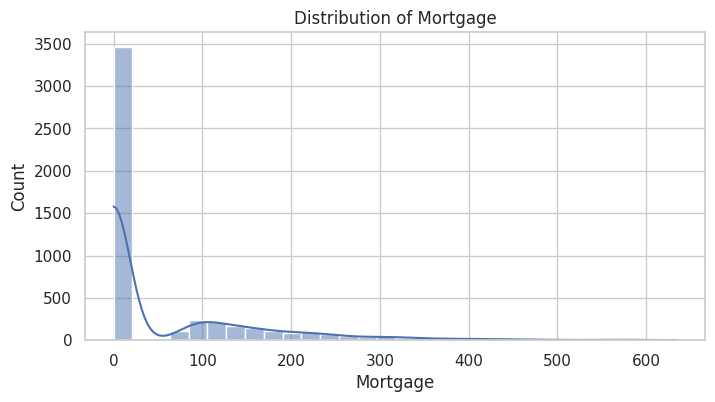

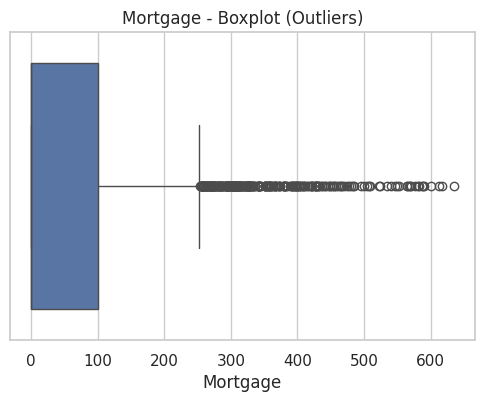

,CreditCard,count
0,0,3530
1,1,1470


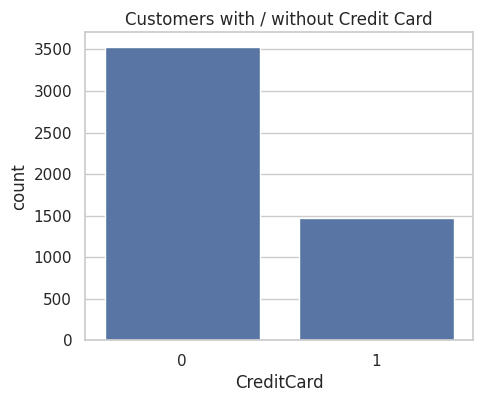

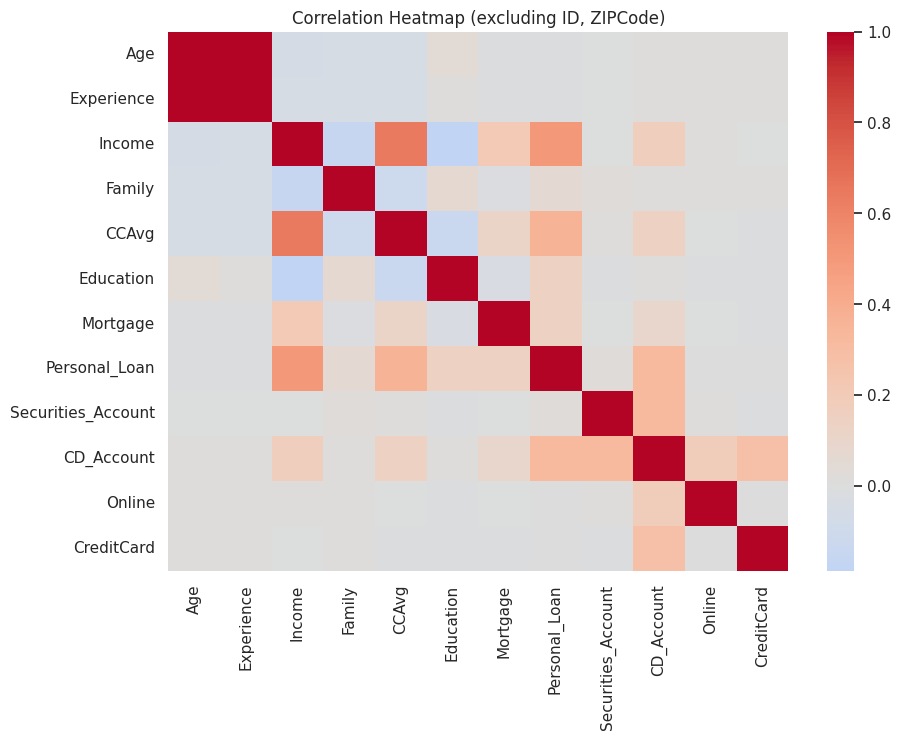

,Personal_Loan
Personal_Loan,1.000000
Income,0.502462
CCAvg,0.366889
CD_Account,0.316355
Mortgage,0.142095
Education,0.136722
Family,0.061367
Securities_Account,0.021954
Online,0.006278
CreditCard,0.002802


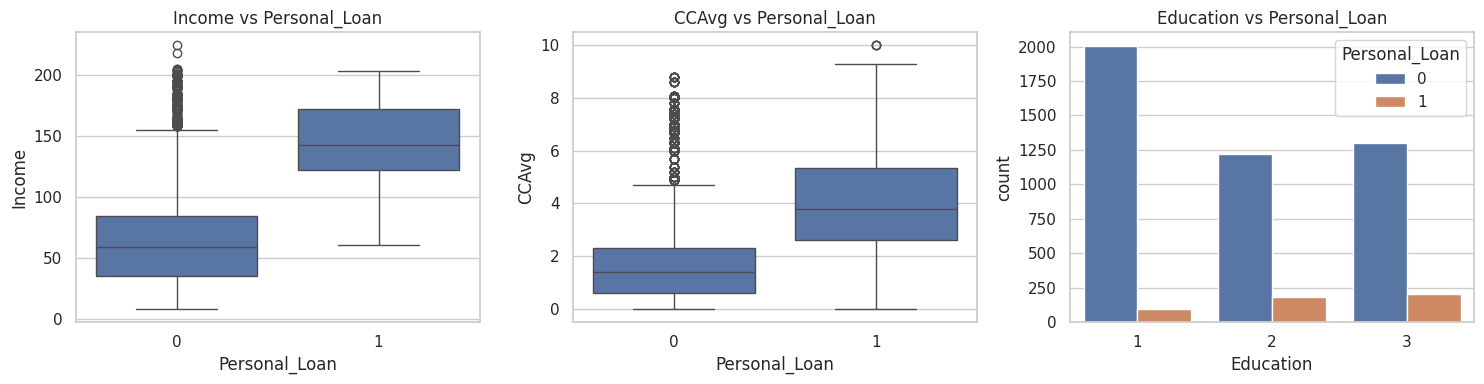

Overall loan conversion rate: 9.60%


In [8]:
# 1) Distribution of Mortgage and outliers
plt.figure(figsize=(8,4))
sns.histplot(df["Mortgage"], bins=30, kde=True)
plt.title("Distribution of Mortgage")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Mortgage"])
plt.title("Mortgage - Boxplot (Outliers)")
plt.show()

# 2) How many customers have credit cards?
cc_counts = df["CreditCard"].value_counts()
display(pd.DataFrame({"CreditCard": cc_counts.index, "count": cc_counts.values}))

plt.figure(figsize=(5,4))
sns.countplot(x="CreditCard", data=df)
plt.title("Customers with / without Credit Card")
plt.show()

# 3) Correlation with target
# (Drop ID as it is just an identifier; keep ZIPCode out of correlation because it is a location code)
corr_df = df.drop(columns=["ID", "ZIPCode"]).corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr_df, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (excluding ID, ZIPCode)")
plt.show()

# Top correlations with target
target_corr = corr_df["Personal_Loan"].sort_values(ascending=False)
display(target_corr)

# Quick comparison of key drivers by target
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x="Personal_Loan", y="Income", data=df, ax=axes[0])
axes[0].set_title("Income vs Personal_Loan")
sns.boxplot(x="Personal_Loan", y="CCAvg", data=df, ax=axes[1])
axes[1].set_title("CCAvg vs Personal_Loan")
sns.countplot(x="Education", hue="Personal_Loan", data=df, ax=axes[2])
axes[2].set_title("Education vs Personal_Loan")
plt.tight_layout()
plt.show()

# Observation helpers
loan_rate = df["Personal_Loan"].mean()
print(f"Overall loan conversion rate: {loan_rate*100:.2f}%")


## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [9]:
# --------- Data Cleaning / Preprocessing ---------

data = df.copy()

# Fix negative Experience values by imputing with the median experience for the same age (fallback to global median)
age_median_exp = data.loc[data["Experience"] >= 0].groupby("Age")["Experience"].median()
global_median_exp = data.loc[data["Experience"] >= 0, "Experience"].median()

def fix_experience(row):
    if row["Experience"] >= 0:
        return row["Experience"]
    return age_median_exp.get(row["Age"], global_median_exp)

data["Experience"] = data.apply(fix_experience, axis=1)

# Drop identifier columns
data = data.drop(columns=["ID", "ZIPCode"])

# Define target and features
X = data.drop(columns=["Personal_Loan"])
y = data["Personal_Loan"]

# Train-test split (stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target rate:", y_train.mean().round(4), " Test target rate:", y_test.mean().round(4))

# Identify categorical and numeric columns
# Education is categorical (1/2/3). All other non-binary numeric columns benefit from scaling.
categorical_cols = ["Education"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

preprocessor


Train shape: (3750, 11)  Test shape: (1250, 11)
Train target rate: 0.096  Test target rate: 0.096


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Experience', 'Income', 'Family',
                                  'CCAvg', 'Mortgage', 'Securities_Account',
                                  'CD_Account', 'Online', 'CreditCard']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Education'])])

## Model Building

### Model Evaluation Criterion

*


### Model Building


=== Logistic Regression (balanced) ===
Confusion Matrix:
[[1018  112]
 [  10  110]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1130
           1       0.50      0.92      0.64       120

    accuracy                           0.90      1250
   macro avg       0.74      0.91      0.79      1250
weighted avg       0.94      0.90      0.91      1250



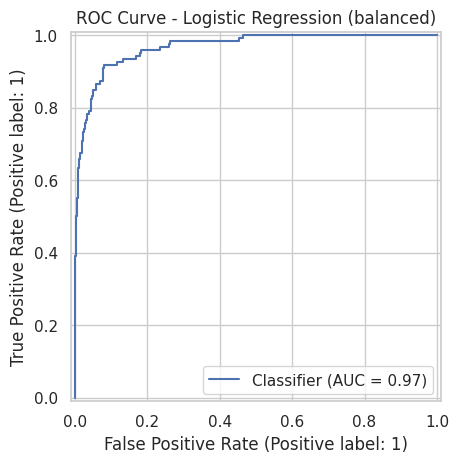


=== Decision Tree (balanced) ===
Confusion Matrix:
[[1118   12]
 [   9  111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1130
           1       0.90      0.93      0.91       120

    accuracy                           0.98      1250
   macro avg       0.95      0.96      0.95      1250
weighted avg       0.98      0.98      0.98      1250



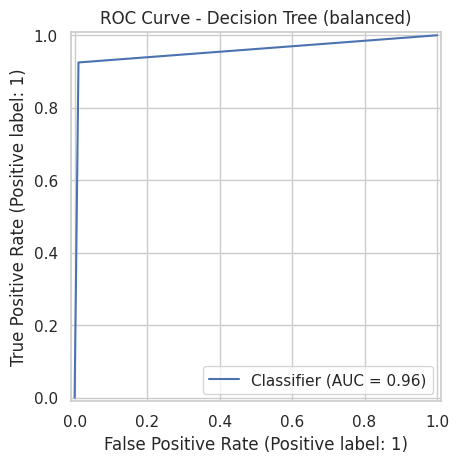


=== Random Forest (balanced_subsample) ===
Confusion Matrix:
[[1128    2]
 [  11  109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1130
           1       0.98      0.91      0.94       120

    accuracy                           0.99      1250
   macro avg       0.99      0.95      0.97      1250
weighted avg       0.99      0.99      0.99      1250



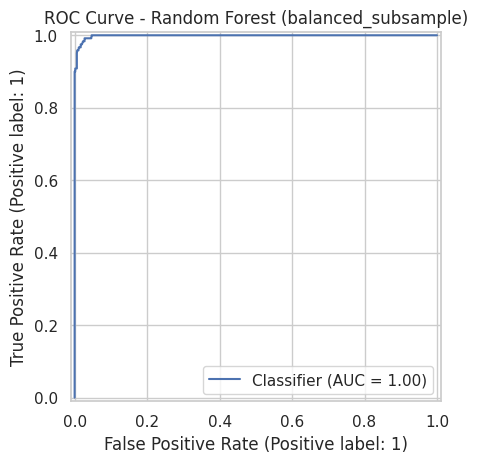

,accuracy,precision,recall,f1,roc_auc
Random Forest,0.9896,0.981982,0.908333,0.943723,0.998643
Logistic Regression,0.9024,0.495495,0.916667,0.643275,0.966600
Decision Tree,0.9832,0.902439,0.925000,0.913580,0.957190


In [10]:
# --------- Model Building & Evaluation ---------
# Because the positive class (loan acceptance) is relatively rare (~10%),
# we will prioritize Recall and F1 along with ROC-AUC.

def evaluate_model(model, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test, model_name="Model"):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    # Some models provide predict_proba; if not, skip ROC-AUC
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_te, y_proba)

    print(f"\n=== {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_te, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_te, y_proba)
        plt.title(f"ROC Curve - {model_name}")
        plt.show()

    return metrics

# 1) Logistic Regression (balanced)
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

# 2) Decision Tree
dtree = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

# 3) Random Forest
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

baseline_results = {}
baseline_results["Logistic Regression"] = evaluate_model(log_reg, model_name="Logistic Regression (balanced)")
baseline_results["Decision Tree"] = evaluate_model(dtree, model_name="Decision Tree (balanced)")
baseline_results["Random Forest"] = evaluate_model(rf, model_name="Random Forest (balanced_subsample)")

baseline_results_df = pd.DataFrame(baseline_results).T
display(baseline_results_df.sort_values(by="roc_auc", ascending=False))


## Model Performance Improvement

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Logistic Regression params: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV ROC-AUC (LR): 0.9622
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest params: {'model__max_depth': 10, 'model__max_features': 0.6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 509}
Best CV ROC-AUC (RF): 0.9971

=== Tuned Logistic Regression ===
Confusion Matrix:
[[1013  117]
 [   9  111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1130
           1       0.49      0.93      0.64       120

    accuracy                           0.90      1250
   macro avg       0.74      0.91      0.79      1250
weighted avg       0.94      0.90      0.91      1250



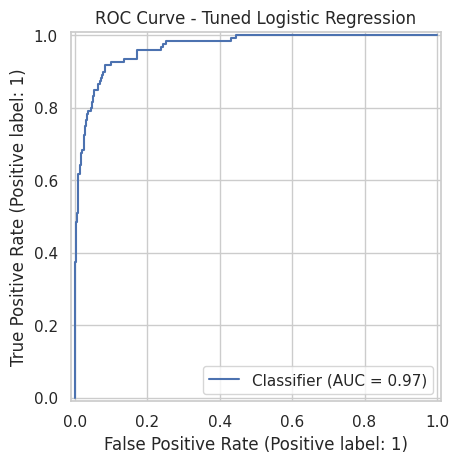


=== Tuned Random Forest ===
Confusion Matrix:
[[1120   10]
 [   6  114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1130
           1       0.92      0.95      0.93       120

    accuracy                           0.99      1250
   macro avg       0.96      0.97      0.96      1250
weighted avg       0.99      0.99      0.99      1250



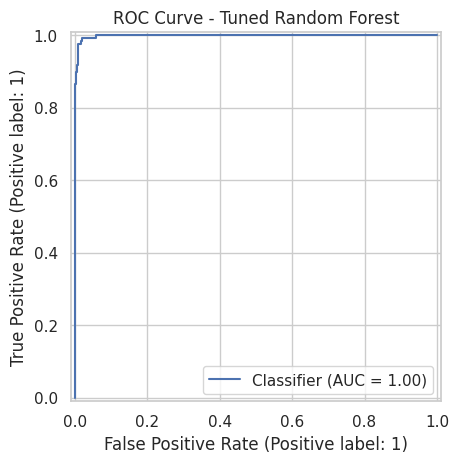

,accuracy,precision,recall,f1,roc_auc
Tuned Random Forest,0.9872,0.919355,0.950,0.934426,0.998451
Tuned Logistic Regression,0.8992,0.486842,0.925,0.637931,0.966541


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# ---------------- Logistic Regression (GridSearchCV) ----------------
log_reg_gs = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=42))
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__solver": ["liblinear", "lbfgs"],
}

gs_lr = GridSearchCV(
    estimator=log_reg_gs,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=3,            # faster than 5
    n_jobs=-1,       # parallelize across folds/params
    verbose=1
)

gs_lr.fit(X_train, y_train)
print("Best Logistic Regression params:", gs_lr.best_params_)
print("Best CV ROC-AUC (LR):", round(gs_lr.best_score_, 4))


# ---------------- Random Forest (RandomizedSearchCV) ----------------
rf_rs = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=1       # IMPORTANT: avoid nested parallelism
    ))
])

param_dist_rf = {
    "model__n_estimators": randint(200, 600),
    "model__max_depth": [None, 6, 8, 10, 12],
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", 0.6, 0.8],
}

rs_rf = RandomizedSearchCV(
    estimator=rf_rs,
    param_distributions=param_dist_rf,
    n_iter=20,        # 20 trials (fast)
    scoring="roc_auc",
    cv=3,             # faster than 5
    n_jobs=-1,        # parallelize the search
    random_state=42,
    verbose=1
)

rs_rf.fit(X_train, y_train)
print("Best Random Forest params:", rs_rf.best_params_)
print("Best CV ROC-AUC (RF):", round(rs_rf.best_score_, 4))


# ---------------- Evaluate tuned models on test set ----------------
tuned_results = {}
tuned_results["Tuned Logistic Regression"] = evaluate_model(
    gs_lr.best_estimator_, model_name="Tuned Logistic Regression"
)
tuned_results["Tuned Random Forest"] = evaluate_model(
    rs_rf.best_estimator_, model_name="Tuned Random Forest"
)

tuned_results_df = pd.DataFrame(tuned_results).T
display(tuned_results_df.sort_values(by="roc_auc", ascending=False))

## Model Performance Comparison and Final Model Selection


=== Tuned Logistic Regression ===
Confusion Matrix:
[[1013  117]
 [   9  111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1130
           1       0.49      0.93      0.64       120

    accuracy                           0.90      1250
   macro avg       0.74      0.91      0.79      1250
weighted avg       0.94      0.90      0.91      1250



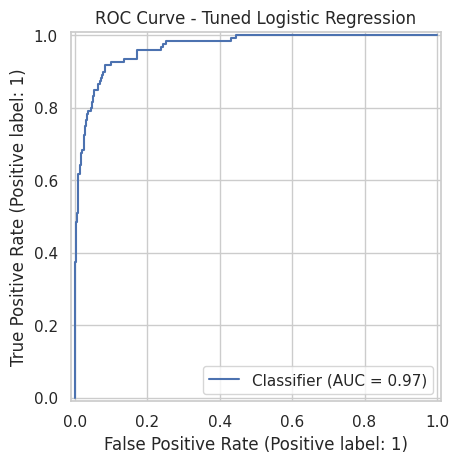


=== Tuned Random Forest ===
Confusion Matrix:
[[1120   10]
 [   6  114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1130
           1       0.92      0.95      0.93       120

    accuracy                           0.99      1250
   macro avg       0.96      0.97      0.96      1250
weighted avg       0.99      0.99      0.99      1250



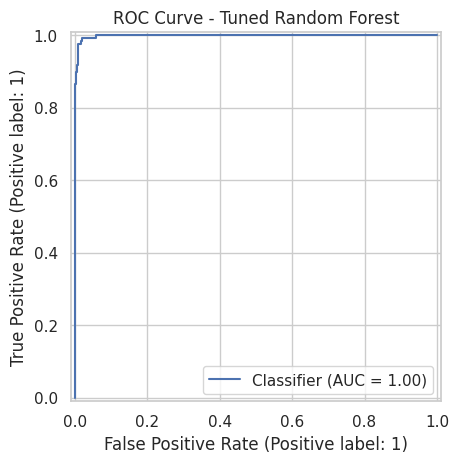

,accuracy,precision,recall,f1,roc_auc
Tuned Random Forest,0.9872,0.919355,0.950,0.934426,0.998451
Tuned Logistic Regression,0.8992,0.486842,0.925,0.637931,0.966541



 Selected Final Model: Tuned Random Forest


=== FINAL: Tuned Random Forest ===
Confusion Matrix:
[[1120   10]
 [   6  114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1130
           1       0.92      0.95      0.93       120

    accuracy                           0.99      1250
   macro avg       0.96      0.97      0.96      1250
weighted avg       0.99      0.99      0.99      1250



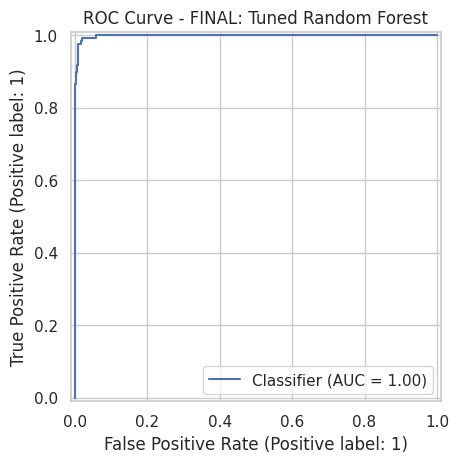

,accuracy,precision,recall,f1,roc_auc
0,0.9872,0.919355,0.95,0.934426,0.998451


Saved final model as: final_loan_model.pkl


In [16]:
import pandas as pd
import joblib

# 1) Evaluate tuned models on test set
comparison_results = {}

comparison_results["Tuned Logistic Regression"] = evaluate_model(
    gs_lr.best_estimator_, model_name="Tuned Logistic Regression"
)

comparison_results["Tuned Random Forest"] = evaluate_model(
    rs_rf.best_estimator_, model_name="Tuned Random Forest"
)

comparison_df = pd.DataFrame(comparison_results).T

# Sort by ROC-AUC (primary). If tie-ish, recall/f1 act as tie-breakers.
sort_cols = [c for c in ["roc_auc", "recall", "f1", "accuracy"] if c in comparison_df.columns]
comparison_df_sorted = comparison_df.sort_values(by=sort_cols, ascending=False)

display(comparison_df_sorted)

# 2) Pick the final model (by best ROC-AUC; if ROC-AUC missing, use Recall)
if "roc_auc" in comparison_df_sorted.columns:
    best_model_name = comparison_df_sorted["roc_auc"].idxmax()
elif "recall" in comparison_df_sorted.columns:
    best_model_name = comparison_df_sorted["recall"].idxmax()
else:
    best_model_name = comparison_df_sorted.index[0]

print(f"\n Selected Final Model: {best_model_name}\n")

# 3) Get the corresponding estimator
final_model = {
    "Tuned Logistic Regression": gs_lr.best_estimator_,
    "Tuned Random Forest": rs_rf.best_estimator_,
}[best_model_name]

# 4) Refit final model on the full training data (recommended)
final_model.fit(X_train, y_train)

# 5) Final evaluation on test set for reporting
final_metrics = evaluate_model(final_model, model_name=f"FINAL: {best_model_name}")
final_metrics_df = pd.DataFrame([final_metrics])
display(final_metrics_df)

# 6) (Optional) Save final model for submission / reuse
joblib.dump(final_model, "final_loan_model.pkl")
print("Saved final model as: final_loan_model.pkl")

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

Based on the test results, the Tuned Random Forest is the best model (ROC-AUC 0.998, Recall 0.95, Precision 0.92). The bank should use it to score customers and focus outreach on high-probability segments to reduce marketing cost and increase conversion. The probability threshold should be adjusted depending on whether the priority is maximizing conversions (higher recall) or minimizing outreach cost (higher precision). A staged outreach strategy (digital first, call second) and continuous monitoring/retraining will ensure sustained performance.

___